In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Load cleaned data and model
df = pd.read_csv('noshow_cleaned.csv')
model = pickle.load(open('noshow_model.pkl', 'rb'))
feature_names = pickle.load(open('feature_names.pkl', 'rb'))

print("Loaded successfully!")
print("Data shape:", df.shape)
print("Features:", feature_names)

Loaded successfully!
Data shape: (71959, 11)
Features: ['Age', 'Scholarship', 'hypertension', 'Diabetes', 'Alcoholism', 'handicap', 'sms_received', 'waiting_days', 'gender_encoded', 'appt_dayofweek']


C:\Users\prabh\AppData\Local\Temp\ipykernel_14524\999563277.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_noshow = df.groupby('age_group')['no_show'].mean() * 100


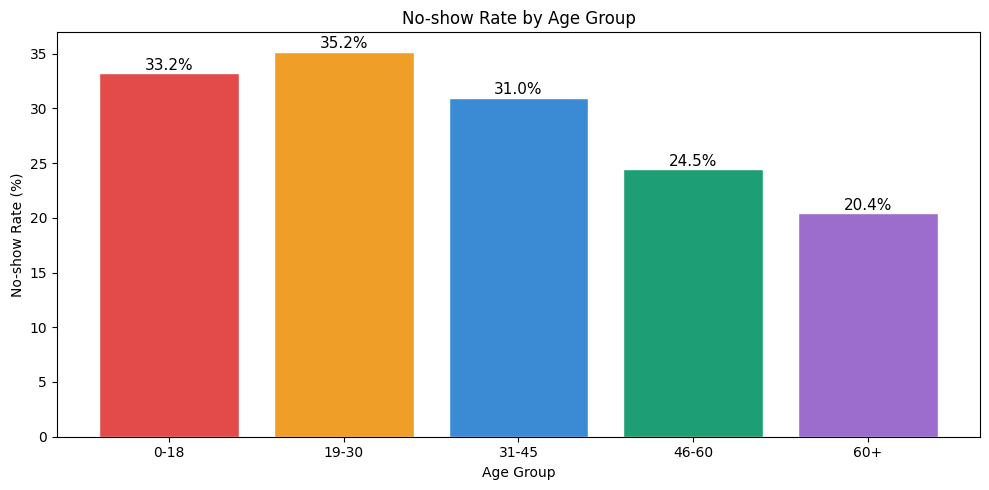

In [2]:
# Create age groups
df['age_group'] = pd.cut(df['Age'], 
                          bins=[0, 18, 30, 45, 60, 100],
                          labels=['0-18', '19-30', '31-45', '46-60', '60+'])

# No-show rate per age group
age_noshow = df.groupby('age_group')['no_show'].mean() * 100

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(age_noshow.index, age_noshow.values, 
               color=['#E24B4A','#EF9F27','#3B8BD4','#1D9E75','#9c6dcc'],
               edgecolor='white')

# Add percentage labels on top of bars
for bar, val in zip(bars, age_noshow.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11)

plt.title('No-show Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('No-show Rate (%)')
plt.tight_layout()
plt.show()

C:\Users\prabh\AppData\Local\Temp\ipykernel_14524\956607429.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wait_noshow = df.groupby('wait_group')['no_show'].mean() * 100


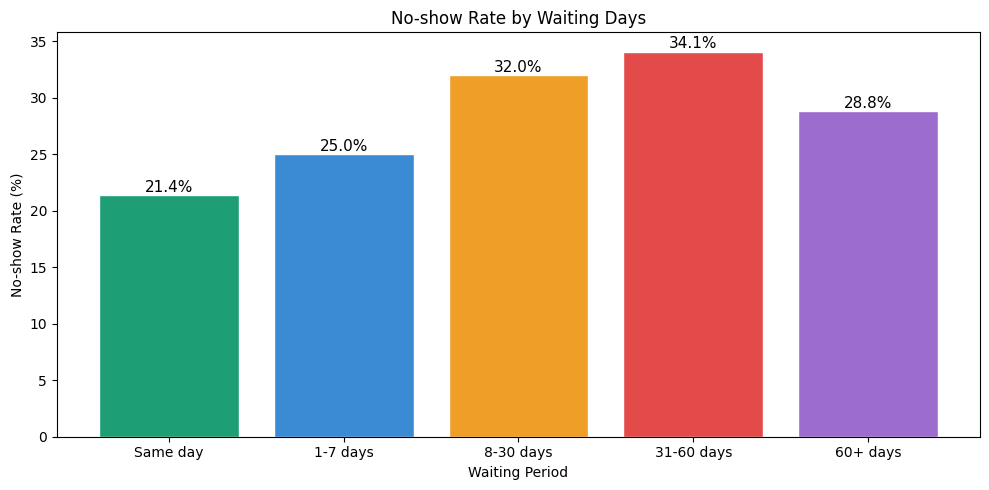

In [3]:
# Group waiting days into buckets
df['wait_group'] = pd.cut(df['waiting_days'],
                           bins=[-1, 0, 7, 30, 60, 180],
                           labels=['Same day', '1-7 days', '8-30 days', '31-60 days', '60+ days'])

# No-show rate per wait group
wait_noshow = df.groupby('wait_group')['no_show'].mean() * 100

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(wait_noshow.index, wait_noshow.values,
               color=['#1D9E75','#3B8BD4','#EF9F27','#E24B4A','#9c6dcc'],
               edgecolor='white')

for bar, val in zip(bars, wait_noshow.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11)

plt.title('No-show Rate by Waiting Days')
plt.xlabel('Waiting Period')
plt.ylabel('No-show Rate (%)')
plt.tight_layout()
plt.show()

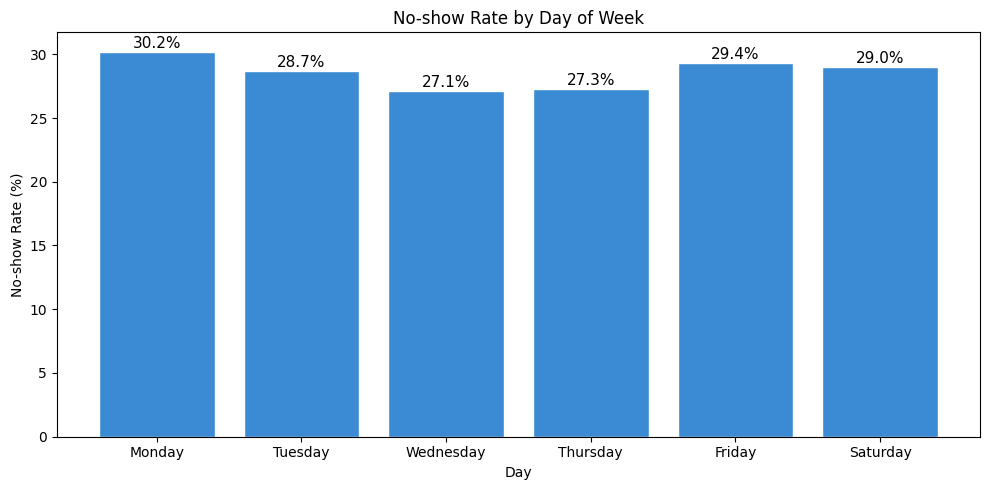

In [4]:
# No-show rate by day of week
day_noshow = df.groupby('appt_dayofweek')['no_show'].mean() * 100
day_labels = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(day_labels[:len(day_noshow)], day_noshow.values,
               color='#3B8BD4', edgecolor='white')

for bar, val in zip(bars, day_noshow.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11)

plt.title('No-show Rate by Day of Week')
plt.xlabel('Day')
plt.ylabel('No-show Rate (%)')
plt.tight_layout()
plt.show()

Risk Distribution:
risk_flag
LOW RISK       41045
HIGH RISK      16015
MEDIUM RISK    14899
Name: count, dtype: int64

Percentage:
risk_flag
LOW RISK       57.0
HIGH RISK      22.3
MEDIUM RISK    20.7
Name: proportion, dtype: float64


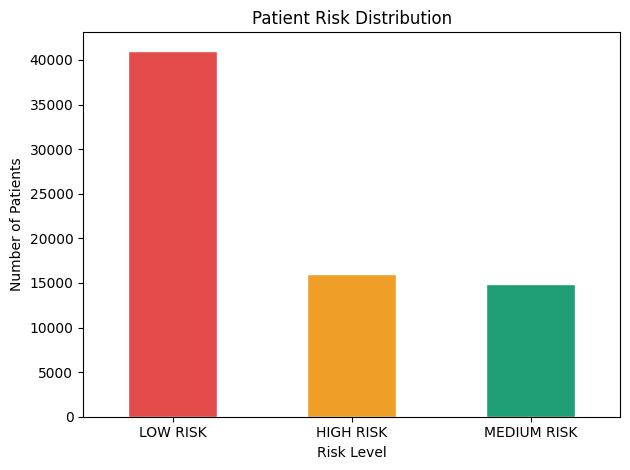

In [5]:
# Prepare features
X = df.drop(columns=['no_show', 'age_group', 'wait_group'])

# Get probability of no-show for every patient
df['noshow_probability'] = model.predict_proba(X)[:, 1] * 100

# Flag patients
def flag_patient(prob):
    if prob >= 60:
        return 'HIGH RISK'
    elif prob >= 35:
        return 'MEDIUM RISK'
    else:
        return 'LOW RISK'

df['risk_flag'] = df['noshow_probability'].apply(flag_patient)

# Summary
print("Risk Distribution:")
print(df['risk_flag'].value_counts())
print("\nPercentage:")
print(df['risk_flag'].value_counts(normalize=True).round(3) * 100)

# Plot
df['risk_flag'].value_counts().plot(
    kind='bar',
    color=['#E24B4A', '#EF9F27', '#1D9E75'],
    edgecolor='white'
)
plt.title('Patient Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# Save flagged patients to CSV
df[['Age', 'waiting_days', 'sms_received', 
    'noshow_probability', 'risk_flag', 'no_show']].to_csv(
    'flagged_patients.csv', index=False
)

print("Saved flagged_patients.csv!")
print("\nSample of HIGH RISK patients:")
df[df['risk_flag'] == 'HIGH RISK'][
    ['Age', 'waiting_days', 'sms_received', 'noshow_probability']
].head(5)

Saved flagged_patients.csv!

Sample of HIGH RISK patients:


,Age,waiting_days,sms_received,noshow_probability
1,23,1,0,68.891298
5,29,2,1,60.714576
10,50,0,0,74.959869
14,4,1,0,83.978290
15,13,3,1,80.339910
